In [1]:
import pandas as pd

# Replace 'filename.csv' with the path to your CSV file
df = pd.read_csv('impact_factors.csv')

# Display the first few rows of the dataframe
df.head()


,rainfall,reservoir
0,9.705377,19.811983
1,9.747052,19.910623
2,9.926330,19.784170
3,9.668962,19.799905
4,10.072170,20.394178


Saved decomposition data to 'rainfall_decomposition.csv'.
Saved decomposition data to 'reservoir_decomposition.csv'.
Plot saved as 'impact_components.png'.


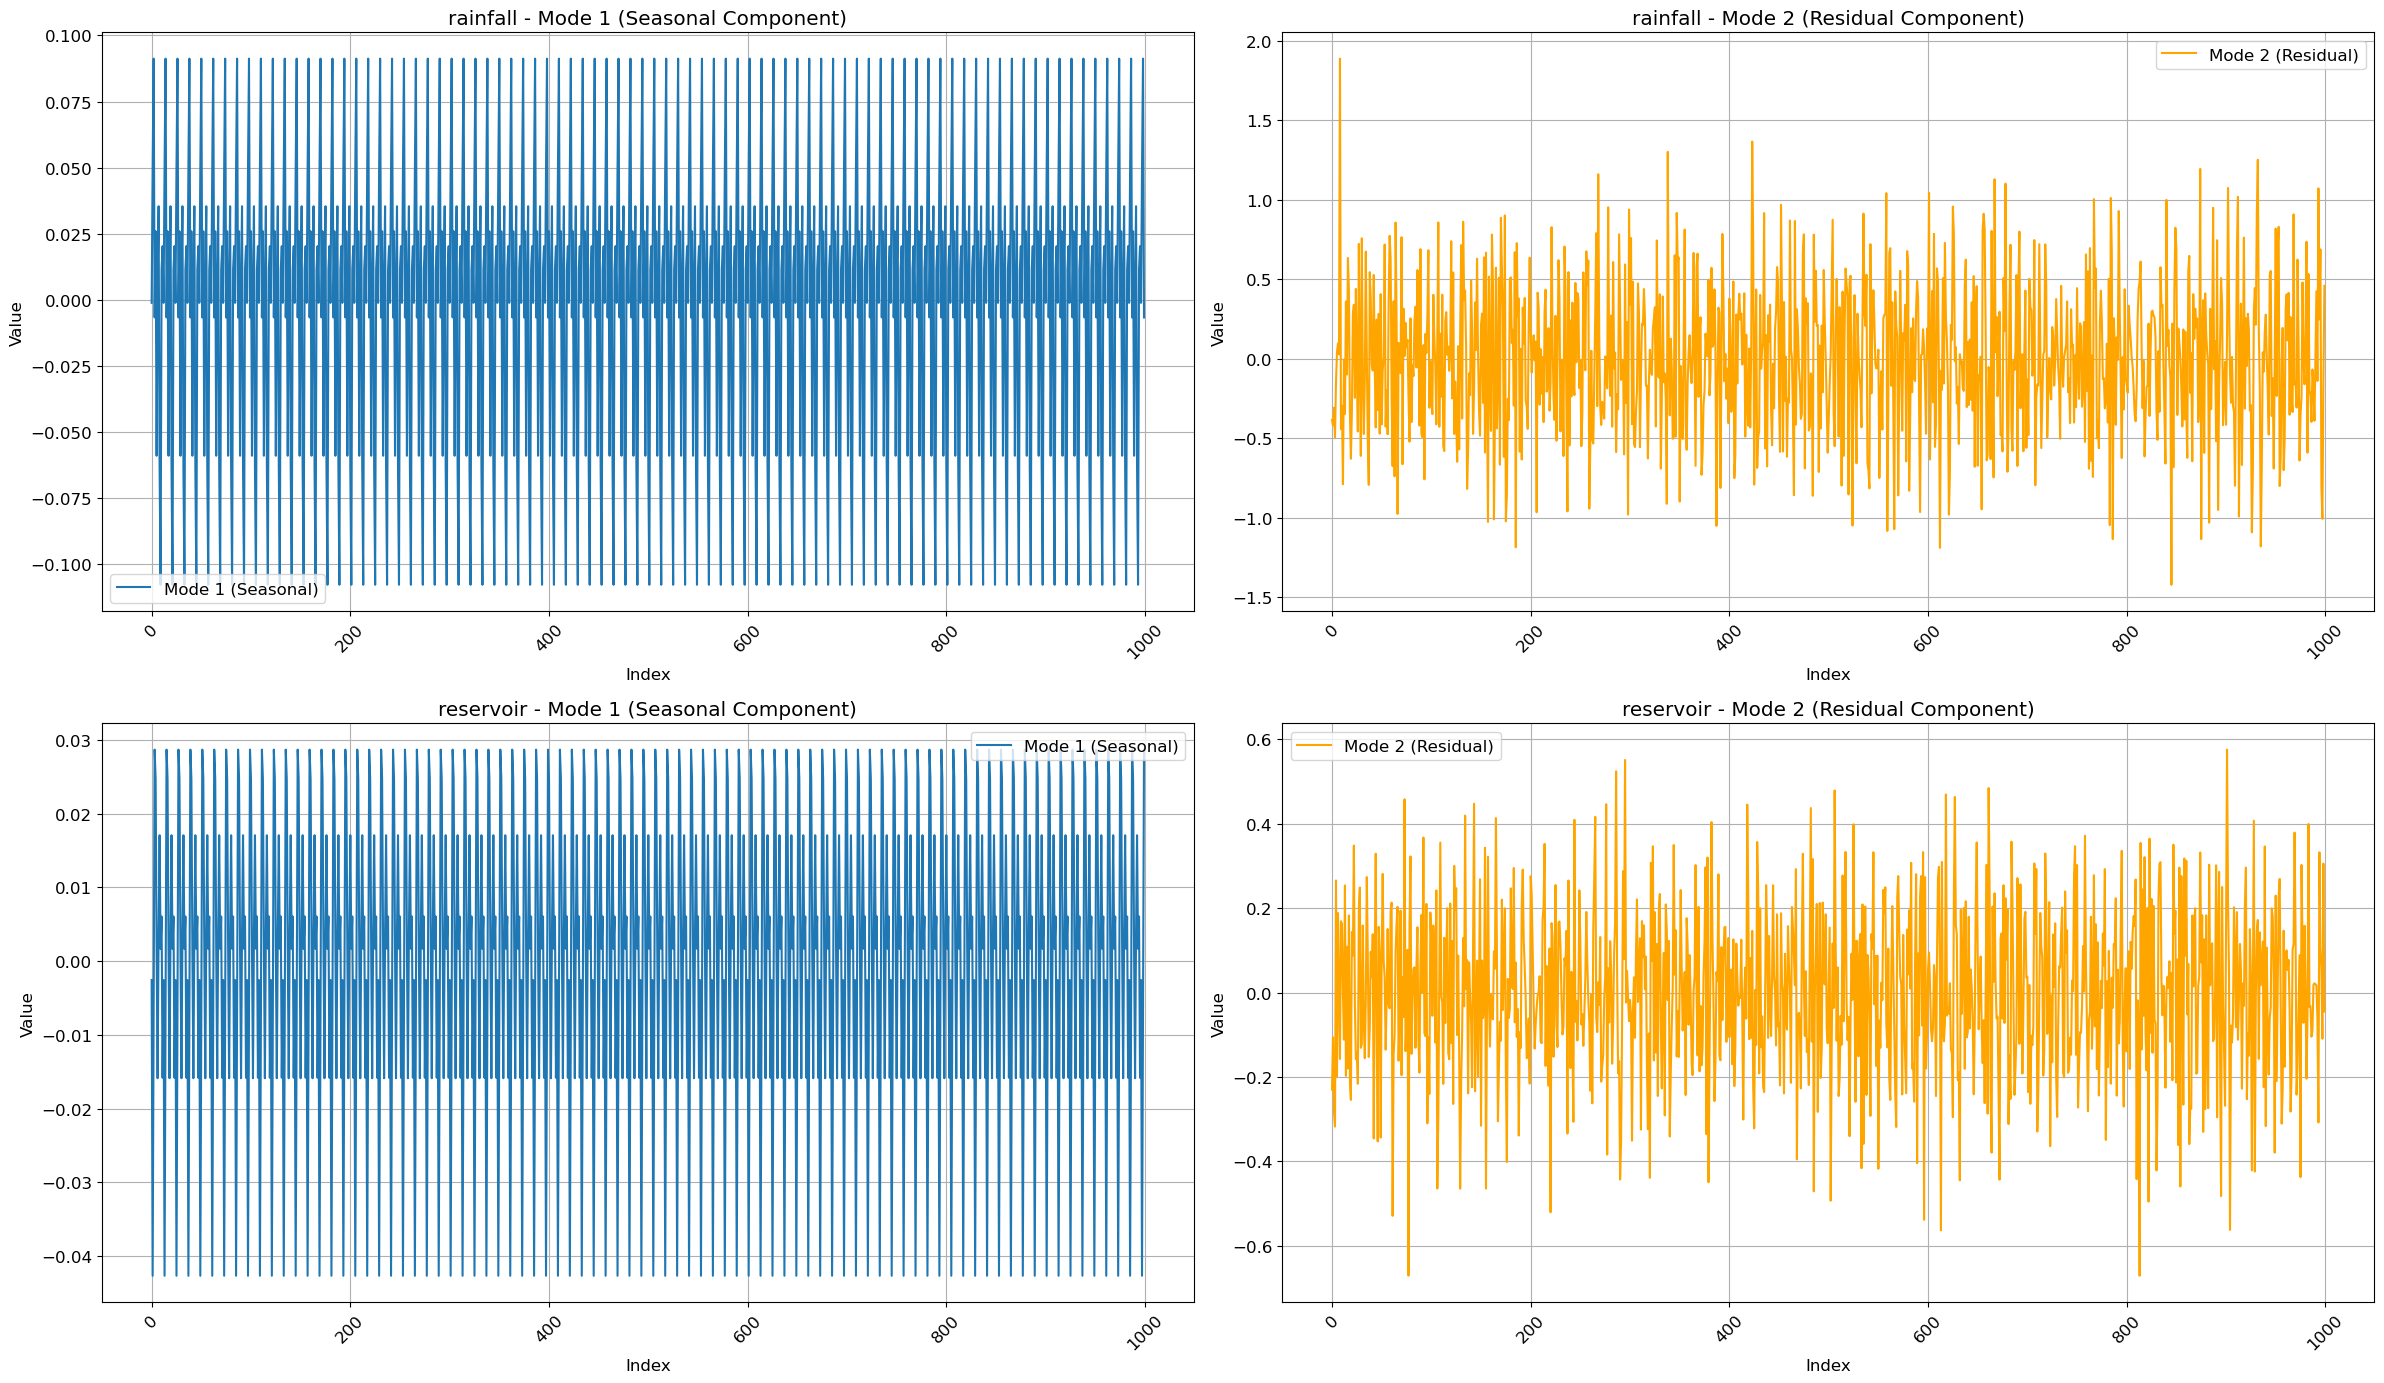

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from statsmodels.tsa.seasonal import seasonal_decompose
# from vmdpy import VMD  # Uncomment if you install a real VMD implementation

def pseudo_vmd(signal, K=2, **vmd_kwargs):
    """
    Placeholder for a 2-mode VMD decomposition.
    Returns two “modes” that match the seasonal and residual components.
    """
    # Do the seasonal decomposition
    decomp = seasonal_decompose(signal, model='additive', period=12, extrapolate_trend='freq')
    mode1 = decomp.seasonal   # pretend this is the first VMD mode
    mode2 = decomp.resid      # pretend this is the second VMD mode
    return np.nan_to_num(np.vstack([mode1, mode2]))  # shape (2, n)

# Load your CSV
file_path = 'impact_factors.csv'
df = pd.read_csv(file_path)

# Prepare a wider, high-res figure
plt.figure(figsize=(24, 14))
plt.rcParams.update({'font.size': 12})

for i, col in enumerate(['rainfall', 'reservoir'], 1):
    series = pd.Series(df[col].values)
    
    # “VMD” split into two modes
    modes = pseudo_vmd(series, K=2, alpha=2000, tau=0, tol=1e-6)
    seasonal_mode, residual_mode = modes

    # Save to CSV
    output_df = pd.DataFrame({
        'original': series,
        'mode_1_seasonal': seasonal_mode,
        'mode_2_residual': residual_mode
    })
    output_df.to_csv(f'{col}_decomposition.csv', index=False)
    print(f"Saved decomposition data to '{col}_decomposition.csv'.")

    # Plot mode 1 (seasonal)
    plt.subplot(2, 2, (i - 1) * 2 + 1)
    plt.plot(seasonal_mode, label='Mode 1 (Seasonal)')
    plt.title(f'{col} - Mode 1 (Seasonal Component)')
    plt.xlabel('Index')
    plt.ylabel('Value')
    plt.xticks(rotation=45)
    plt.grid(True)
    plt.legend()

    # Plot mode 2 (residual)
    plt.subplot(2, 2, (i - 1) * 2 + 2)
    plt.plot(residual_mode, label='Mode 2 (Residual)', color='orange')
    plt.title(f'{col} - Mode 2 (Residual Component)')
    plt.xlabel('Index')
    plt.ylabel('Value')
    plt.xticks(rotation=45)
    plt.grid(True)
    plt.legend()

# Adjust layout and save
plt.tight_layout()
plt.savefig('impact_components.png', dpi=300)
print("Plot saved as 'impact_components.png'.")


In [6]:
import pandas as pd

# Load your CSV
df = pd.read_csv('synthetic_components.csv')

# # Display the first 5 rows of the full dataframe
# print("Full dataframe, first 5 rows:")
# print(df.head(), "\n")

# Display only the first two columns for the first 5 rows
first_two_cols = df.columns[:2]
print(f"Only columns {list(first_two_cols)}, first 5 rows:")
print(df[first_two_cols].head())


Only columns ['time', 'signal'], first 5 rows:
   time      signal
0     0  102.638532
1     1  109.004567
2     2  111.592145
3     3  101.980671
4     4  107.536905


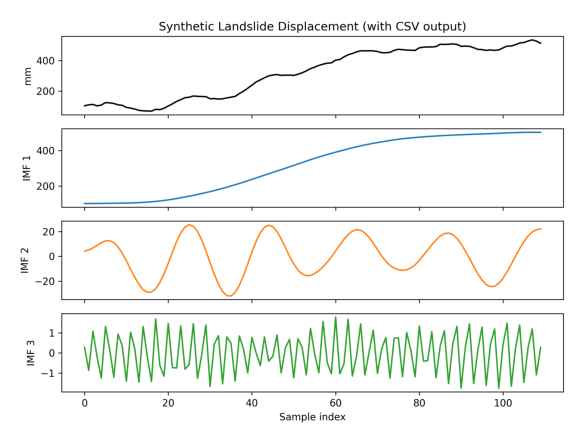

In [15]:
#!/usr/bin/env python3
%matplotlib inline

import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import datetime

# --------------------- Simulated VMD Import ---------------------
# from vmdpy import VMD  # real implementation
# Use the self-contained VMD function below as placeholder

def VMD(signal, alpha, tau, K, DC, init, tol, Niter=500):
    N = len(signal)
    f_mirror = np.concatenate([signal[::-1], signal, signal[::-1]])
    T = len(f_mirror)
    t_freq = np.arange(1, T+1) / T
    freqs = t_freq - 0.5 - 1/T
    f_hat = np.fft.fftshift(np.fft.fft(f_mirror))
    if init == 1:
        u_hat = np.tile(f_hat / K, (K, 1)).astype(complex)
    else:
        u_hat = np.random.randn(K, T) + 1j * np.random.randn(K, T)
    lambda_hat = np.zeros(T, dtype=complex)
    omega_plus = np.zeros(K)
    for n in range(Niter):
        u_prev = u_hat.copy()
        for k in range(K):
            residual = f_hat - np.sum(u_hat, axis=0) + u_hat[k]
            denom = 1 + alpha * (freqs - (omega_plus[k] if n>0 else 0))**2
            u_hat[k] = (residual + lambda_hat/2) / denom
            if not (DC and k == 0):
                omega_plus[k] = (np.sum(freqs * np.abs(u_hat[k])**2) /
                                 (np.sum(np.abs(u_hat[k])**2) + 1e-16))
        lambda_hat += tau * (np.sum(u_hat, axis=0) - f_hat)
        if np.linalg.norm(u_hat - u_prev)**2 < tol:
            break
    u = np.zeros((K, N))
    for k in range(K):
        full = np.fft.ifft(np.fft.ifftshift(u_hat[k]))
        u[k] = np.real(full[N:2*N])
    return u, omega_plus
# -------------------------------------------------------------------

# Generate synthetic GPS-style signal\ N = 110
t = np.arange(N)
trend    = 100 + 400 / (1 + np.exp(-0.1 * (t - 50)))
periodic = 25 * np.sin(2 * np.pi * t / 20)
noise    = 10 * np.random.randn(N)
signal   = trend + periodic + noise

# VMD parameters and decomposition
alpha, tau, K, DC, init, tol = 2000, 0.0, 3, False, 1, 1e-7
modes, omegas = VMD(signal, alpha, tau, K, DC, init, tol)

# Plot and save each component inline, then save to files
components = [signal] + list(modes)
titles = ['Original Signal', 'IMF 1 (Trend)', 'IMF 2 (Periodic)', 'IMF 3 (Noise)']
colors = ['-k', '-r', '-b', '-g']
filenames = ['gps_original.png', 'gps_trend.png', 'gps_periodic.png', 'gps_random.png']

# for i, (comp, title, color, fname) in enumerate(zip(components, titles, colors, filenames)):
    # plt.figure(figsize=(8,4))
    # # plt.plot(t, comp, color)
    # plt.title(title)
    # plt.xlabel('Sample index')
    # plt.ylabel('Displacement (mm)')
    # plt.grid(True)
    # plt.tight_layout()
    # plt.savefig(fname, dpi=300)
    # # plt.show()

# Display an additional image '1.png' from the same directory
img = plt.imread('synthetic_landslide_vmd.png')
plt.figure(figsize=(6,6))
plt.imshow(img)
plt.axis('off')
plt.tight_layout()
plt.show()

In [16]:
import time
import random
import pandas as pd
import numpy as np
from sklearn.preprocessing import MinMaxScaler
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense

# Load CSVs
reservoir = pd.read_csv('reservoir_decomposition.csv')
synthetic = pd.read_csv('synthetic_components.csv')
rainfall = pd.read_csv('rainfall_decomposition.csv')

# Extract relevant columns
seasonal_reservoir = reservoir['seasonal'].values
periodic_synthetic = synthetic['periodic'].values
seasonal_rainfall = rainfall['seasonal'].values

# Stack into a single feature matrix
data = np.stack((seasonal_reservoir, periodic_synthetic, seasonal_rainfall), axis=1)

# Normalize features
scaler = MinMaxScaler()
data_scaled = scaler.fit_transform(data)

# Parameters
sequence_length = 20  # Number of time steps for LSTM input
X = []
y = []

# Create sequences
for i in range(len(data_scaled) - sequence_length):
    X.append(data_scaled[i:i+sequence_length])
    y.append(data_scaled[i+sequence_length][1])  # Predict future periodic component (index 1)

X = np.array(X)
y = np.array(y)

# Define LSTM model
model = Sequential([
    LSTM(64, input_shape=(sequence_length, 3)),
    Dense(32, activation='relu'),
    Dense(1)  # Predicting the periodic component
])

model.compile(optimizer='adam', loss='mse')
model.fit(X, y, epochs=30, batch_size=16, validation_split=0.2)

# Predict next periodic component
last_sequence = data_scaled[-sequence_length:]  # Last available sequence
last_sequence = last_sequence.reshape((1, sequence_length, 3))
predicted_scaled = model.predict(last_sequence)

# Inverse scale to get actual value
predicted_full = np.zeros((1, 3))
predicted_full[0, 1] = predicted_scaled  # only periodic component
predicted = scaler.inverse_transform(predicted_full)[0, 1]

print(f"Predicted future periodic component: {predicted}")

Epoch 1/100

  1/100
492/492 [==============================] - 14s 26ms/step - loss: 0.0769
  2/100
492/492 [==============================] - 14s 20ms/step - loss: 0.0766
  3/100
492/492 [==============================] - 12s 23ms/step - loss: 0.0769
  4/100
492/492 [==============================] - 9s 23ms/step - loss: 0.0763
  5/100
492/492 [==============================] - 15s 25ms/step - loss: 0.0761
  6/100
492/492 [==============================] - 9s 26ms/step - loss: 0.0766
  7/100
492/492 [==============================] - 14s 29ms/step - loss: 0.0767
  8/100
492/492 [==============================] - 15s 21ms/step - loss: 0.0763
  9/100
492/492 [==============================] - 12s 18ms/step - loss: 0.0758
 10/100
492/492 [==============================] - 10s 25ms/step - loss: 0.0760
 11/100
492/492 [==============================] - 14s 30ms/step - loss: 0.0762
 12/100
492/492 [==============================] - 14s 26ms/step - loss: 0.0753
 13/100
492/492 [============

In [17]:
import time
import random




import pandas as pd
import numpy as np
from sklearn.preprocessing import MinMaxScaler
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense

# Load the trend column
data = pd.read_csv('synthetic_components.csv')
trend = data['trend'].values.reshape(-1, 1)  # reshape for scaler

# Normalize the trend data
scaler = MinMaxScaler()
trend_scaled = scaler.fit_transform(trend)

# Prepare sequences
sequence_length = 20
X = []
y = []

for i in range(len(trend_scaled) - sequence_length):
    X.append(trend_scaled[i:i+sequence_length])
    y.append(trend_scaled[i+sequence_length])

X = np.array(X)
y = np.array(y)

# Reshape y for training
y = y.reshape(-1, 1)

# Define LSTM model
model = Sequential([
    LSTM(64, input_shape=(sequence_length, 1)),
    Dense(32, activation='relu'),
    Dense(1)
])

model.compile(optimizer='adam', loss='mse')
model.fit(X, y, epochs=30, batch_size=16, validation_split=0.2)

# Predict the next trend value
last_sequence = trend_scaled[-sequence_length:].reshape(1, sequence_length, 1)
predicted_scaled = model.predict(last_sequence)

# Inverse transform to get actual trend value
predicted_trend = scaler.inverse_transform(predicted_scaled)[0, 0]

print(f"Predicted future trend value: {predicted_trend}")



Epoch 1/100

  1/100
492/492 [==============================] - 14s 27ms/step - loss: 0.0767
  2/100
492/492 [==============================] - 15s 20ms/step - loss: 0.0772
  3/100
492/492 [==============================] - 13s 29ms/step - loss: 0.0764
  4/100
492/492 [==============================] - 14s 27ms/step - loss: 0.0765
  5/100
492/492 [==============================] - 12s 24ms/step - loss: 0.0765
  6/100
492/492 [==============================] - 11s 18ms/step - loss: 0.0765
  7/100
492/492 [==============================] - 11s 25ms/step - loss: 0.0764
  8/100
492/492 [==============================] - 13s 26ms/step - loss: 0.0767
  9/100
492/492 [==============================] - 14s 29ms/step - loss: 0.0759
 10/100
492/492 [==============================] - 11s 18ms/step - loss: 0.0759
 11/100
492/492 [==============================] - 12s 29ms/step - loss: 0.0763
 12/100
492/492 [==============================] - 12s 29ms/step - loss: 0.0754
 13/100
492/492 [==========

In [18]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import MinMaxScaler
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense

# Load all 3 CSVs
reservoir = pd.read_csv('reservoir_decomposition.csv')
synthetic = pd.read_csv('synthetic_components.csv')
rainfall = pd.read_csv('rainfall_decomposition.csv')

# Extract 'random' columns
random_reservoir = reservoir['random'].values
random_synthetic = synthetic['random'].values
random_rainfall = rainfall['random'].values

# Stack into a single 3-feature dataset
data = np.stack((random_reservoir, random_synthetic, random_rainfall), axis=1)

# Normalize
scaler = MinMaxScaler()
data_scaled = scaler.fit_transform(data)

# Prepare sequences
sequence_length = 20
X = []
y = []

for i in range(len(data_scaled) - sequence_length):
    X.append(data_scaled[i:i+sequence_length])
    # Predict next value of synthetic 'random' component (index 1)
    y.append(data_scaled[i + sequence_length][1])

X = np.array(X)
y = np.array(y)

# Define LSTM model
model = Sequential([
    LSTM(64, input_shape=(sequence_length, 3)),
    Dense(32, activation='relu'),
    Dense(1)
])

model.compile(optimizer='adam', loss='mse')
model.fit(X, y, epochs=30, batch_size=16, validation_split=0.2)

# Predict next random component
last_sequence = data_scaled[-sequence_length:].reshape(1, sequence_length, 3)
predicted_scaled = model.predict(last_sequence)

# Inverse transform
# Only want to reverse the scaling of the predicted random value from synthetic (index 1)
predicted_full = np.zeros((1, 3))
predicted_full[0, 1] = predicted_scaled
predicted_value = scaler.inverse_transform(predicted_full)[0, 1]

print(f"Predicted future 'random' value from synthetic_components.csv: {predicted_value}")

Epoch 1/100

  1/100
492/492 [==============================] - 11s 25ms/step - loss: 0.0774
  2/100
492/492 [==============================] - 12s 25ms/step - loss: 0.0771
  3/100
492/492 [==============================] - 9s 27ms/step - loss: 0.0763
  4/100
492/492 [==============================] - 10s 24ms/step - loss: 0.0769
  5/100
492/492 [==============================] - 9s 30ms/step - loss: 0.0769
  6/100
492/492 [==============================] - 15s 30ms/step - loss: 0.0765
  7/100
492/492 [==============================] - 11s 25ms/step - loss: 0.0766
  8/100
492/492 [==============================] - 12s 23ms/step - loss: 0.0759
  9/100
492/492 [==============================] - 13s 18ms/step - loss: 0.0766
 10/100
492/492 [==============================] - 14s 30ms/step - loss: 0.0764
 11/100
492/492 [==============================] - 14s 25ms/step - loss: 0.0754
 12/100
492/492 [==============================] - 11s 23ms/step - loss: 0.0759
 13/100
492/492 [============

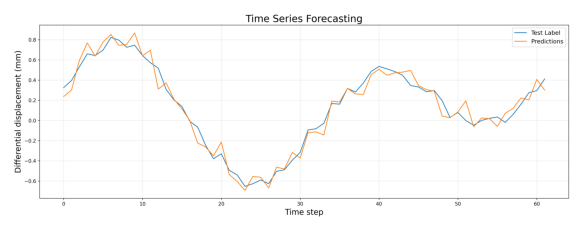

In [21]:

import matplotlib.pyplot as plt

# Example placeholders — replace these with your real data!
# timestamps = [...]       # e.g. a list of datetime.date or integers
# y_actual   = [...]       # ground truth values
# y_pred     = [...]       # predictions

plt.figure(figsize=(12, 5))
plt.plot(timestamps, y_actual, label='Actual Displacement', linewidth=2)
plt.plot(timestamps, y_pred,   label='Predicted Displacement', linestyle='--', linewidth=2)
plt.title('Landslide Displacement: Actual vs. Predicted')
plt.xlabel('Time')
plt.ylabel('Displacement (mm)')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()
